# CR-300 P(k) two-panel figure — tweak fonts and layout here

Left: |P(k) relative error| vs k for each method's **first compliant** model.
Right: the requirement metric itself (max over k < 10) against pure training
wall time, best-so-far within the budget, both starting from the SZ3 base.

PSNR is deliberately not an axis: compliance is a spectral property and is
decoupled from PSNR (Ours is at 125.5 dB when it first complies at 3 s,
NeurLZ at 119.9 dB when it first complies at 107 s).

**Everything you would normally want to change is in the next cell** — font
sizes are `FS` and the `FS_*` derived from it. Run all cells; the last one
writes `pk_time_2panel_cr300.pdf` (+ `.png`).
Mirrors `plot_pk_time_2panel_cr300.py`; keep the two in sync if you edit here.

In [1]:
import json, os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Pin the look: a notebook otherwise inherits fonts/weights from whichever
# kernel and IPython profile happen to be active, so the same code renders
# differently here than from plot_pk_time_2panel_cr300.py.
plt.rcdefaults()
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
    "font.weight": "normal",
    "axes.labelweight": "normal",
    "axes.titleweight": "normal",
    "figure.dpi": 100,
    "savefig.facecolor": "white",
})

# ── DATA ────────────────────────────────────────────────────────────────────
OUT_DIR = "ps3d_out"          # Gimlet2 sim_stats output (…_rhob_ps3d.txt)
K_MAX   = 10.0                # only k < K_MAX is required to meet 1%
REQ     = 1.0                 # the Nyx requirement, in %
OUT     = "pk_time_2panel_cr300.pdf"     # .png written alongside

# Ours: batch-1 budget-matched runs (seed 17). (epochs, wall seconds, tag)
OURS = [(1, 3.12, "cr300_ours_b1ep1"), (2, 5.61, "cr300_ours_b1ep2"),
        (3, 8.13, "cr300_ours_b1ep3"), (4, 10.66, "cr300_ours_b1ep4"),
        (5, 13.1, "cr300_ours_b1ep5"), (6, 15.6, "cr300_ours_b1ep6"),
        (8, 20.6, "cr300_ours_b1ep8"), (10, 26.1, "cr300_sz3_ours")]
NLZ_JSON = ("../../recons/"
            "recons_exp/NYX_baryon_density__cr300_sz3_neurlz_ep100_results_ckrun.json")
NLZ_CKPTS = list(range(10, 101, 10))     # checkpoints saved every 10 epochs
SZ3_TAG = "cr300_sz3"

# ── TEXT ────────────────────────────────────────────────────────────────────
SUPTITLE  = "NYX Baryon Density @ CR 300"
TITLE_L   = r"Power-spectrum error $\varepsilon(k)$"
TITLE_R   = "Time to meet the 1% requirement"
XLABEL_L  = "k"
YLABEL_L  = r"$\varepsilon(k)$ (%)"
XLABEL_R  = "Pure training wall time (s)"
YLABEL_R  = r"best $\max_k \varepsilon(k)$ (%)"
LAB_REQ   = "Nyx 1% requirement"
LAB_SZ3   = "SZ3"
LAB_NLZ   = "SZ3+NeurLZ"      # " ({t:.0f} s)" is appended from the data
LAB_OURS  = "SZ3+Ours"        # ditto

# ── LAYOUT / FONTS (the knobs) ──────────────────────────────────────────────
FIGSIZE    = (9.5,4)
FS         = 15        # base; everything else is FS +/- n
FS_TITLE   = FS + 1
FS_SUP     = FS + 2
FS_TICK    = FS
FS_LEG_L   = FS       # left panel has 4 entries -> smaller
FS_LEG_R   = FS 
BOLD_LABELS = True       # bold axis labels & titles
XLIM_R     = (-4, 162)
YLIM_R     = (0, 2.9)
LEG_LOC_L, LEG_LOC_R = "upper right", "upper right"

# ── STYLE ───────────────────────────────────────────────────────────────────
C_SZ3, C_NLZ, C_OURS, C_REQ = "tab:gray", "tab:red", "tab:blue", "tab:orange"
LW, MS = 1.8, 12         # line width, marker size (left panel)
MS_R      = 10           # marker size (right panel)
MS_FIRST  = 14           # the filled "first compliant" marker
MEW       = 1.4          # marker edge width
GRID_ALPHA = 0.3

In [2]:
ori = np.loadtxt(f"{OUT_DIR}/ori_rhob_ps3d.txt")
k, po = ori[:, 2], ori[:, 3]
m = k < K_MAX

def relabs(tag):
    """|P(k) relative error| in %, per k-bin, for one reconstruction."""
    d = np.loadtxt(f"{OUT_DIR}/{tag}_rhob_ps3d.txt")
    assert np.array_equal(ori[:, 1], d[:, 1]), f"{tag}: k-bins not aligned with ori"
    return np.abs((d[:, 3] - po) / po) * 100

def mx(tag):
    """The compliance metric: max over the required k-range."""
    return float(relabs(tag)[m].max())

BASE_MAX = mx(SZ3_TAG)
ours = [(e, t, tag) for e, t, tag in OURS
        if os.path.isfile(f"{OUT_DIR}/{tag}_rhob_ps3d.txt")]
ours_t = [0.0] + [t for _, t, _ in ours]
ours_y = [BASE_MAX] + [mx(tag) for _, _, tag in ours]

h = json.load(open(NLZ_JSON))[0]["history"]      # (epoch, wall_s, psnr)
t_of = {ep: t for ep, t, _ in h}
nlz_t = [0.0] + [t_of[ep] for ep in NLZ_CKPTS]
nlz_y = [BASE_MAX] + [mx(f"cr300_nlz_ck{ep}") for ep in NLZ_CKPTS]

# Best-so-far on the compliance metric: the best checkpoint within a budget,
# the same convention the time-to-PSNR figure uses. Without it a later, worse
# checkpoint would make the curve non-monotone in budget.
ours_y = list(np.minimum.accumulate(ours_y))
nlz_y = list(np.minimum.accumulate(nlz_y))

o_first = next((t, y) for t, y in zip(ours_t[1:], ours_y[1:]) if y <= REQ)
n_first = next((t, y) for t, y in zip(nlz_t[1:], nlz_y[1:]) if y <= REQ)
o_tag = next(tag for _, t, tag in ours if mx(tag) <= REQ)      # left-panel line
n_tag = f"cr300_nlz_ck{NLZ_CKPTS[nlz_y[1:].index(n_first[1])]}"

print(f"SZ3 base max        {BASE_MAX:.3f}%")
print(f"Ours   first <= 1%: {o_first[0]:5.1f} s  ({o_first[1]:.3f}%)  [{o_tag}]")
print(f"NeurLZ first <= 1%: {n_first[0]:5.1f} s  ({n_first[1]:.3f}%)  [{n_tag}]")

SZ3 base max        1.635%
Ours   first <= 1%:   3.1 s  (0.268%)  [cr300_ours_b1ep1]
NeurLZ first <= 1%: 106.8 s  (0.469%)  [cr300_nlz_ck70]


wrote pk_time_2panel_cr300.pdf


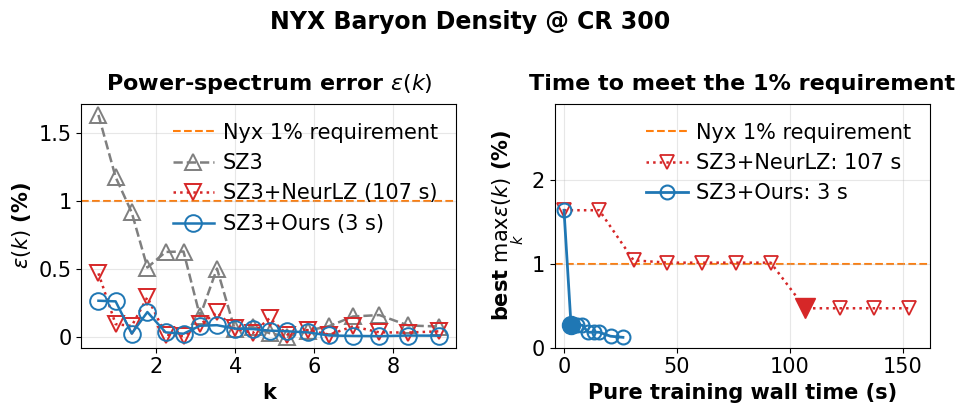

In [3]:
# The inline backend re-applies its own rc on every execution, so pin the look
# here, immediately before the figure is built, rather than in the config cell.
plt.rcdefaults()
plt.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans"],
    "font.weight": "normal", "axes.labelweight": "normal",
    "axes.titleweight": "normal", "figure.dpi": 100,
    "savefig.facecolor": "white",
})
BW = "bold" if BOLD_LABELS else "normal"

fig, (axL, axR) = plt.subplots(1, 2, figsize=FIGSIZE)

# ── left: the spectrum of each method's FIRST compliant model ───────────────
axL.axhline(REQ, color=C_REQ, ls="--", lw=1.5, zorder=1, label=LAB_REQ)
axL.plot(k[m], relabs(SZ3_TAG)[m], color=C_SZ3, marker="^", ls="--", lw=LW,
         markerfacecolor="none", markeredgewidth=MEW, markersize=MS,
         label=LAB_SZ3, zorder=3)
axL.plot(k[m], relabs(n_tag)[m], color=C_NLZ, marker="v", ls=":", lw=LW,
         markerfacecolor="none", markeredgecolor=C_NLZ, markeredgewidth=MEW,
         markersize=MS, label=f"{LAB_NLZ} ({n_first[0]:.0f} s)", zorder=4)
axL.plot(k[m], relabs(o_tag)[m], color=C_OURS, marker="o", ls="-", lw=LW,
         markerfacecolor="none", markeredgecolor=C_OURS, markeredgewidth=MEW,
         markersize=MS, label=f"{LAB_OURS} ({o_first[0]:.0f} s)", zorder=5)
axL.set_xlabel(XLABEL_L, fontsize=FS, fontweight=BW)
axL.set_ylabel(YLABEL_L, fontsize=FS, fontweight=BW)
axL.set_title(TITLE_L, fontsize=FS_TITLE, pad=10, fontweight=BW)
axL.legend(loc=LEG_LOC_L, fontsize=FS_LEG_L, frameon=False, handletextpad=0.4)

# ── right: the requirement metric itself, against training time ─────────────
axR.axhline(REQ, color=C_REQ, ls="--", lw=1.5, zorder=1, label=LAB_REQ)
axR.plot(nlz_t, nlz_y, color=C_NLZ, ls=":", lw=LW, marker="v", markersize=MS_R,
         markerfacecolor="none", markeredgecolor=C_NLZ, markeredgewidth=1.3,
         label=f"{LAB_NLZ}: {n_first[0]:.0f} s", zorder=3)
axR.plot([n_first[0]], [n_first[1]], marker="v", color=C_NLZ, ls="none",
         markersize=MS_FIRST + 1, markerfacecolor=C_NLZ, zorder=5)
axR.plot(ours_t, ours_y, color=C_OURS, ls="-", lw=LW + 0.2, marker="o",
         markersize=MS_R, markerfacecolor="none", markeredgecolor=C_OURS,
         markeredgewidth=1.5, label=f"{LAB_OURS}: {o_first[0]:.0f} s", zorder=5)
axR.plot([o_first[0]], [o_first[1]], marker="o", color=C_OURS, ls="none",
         markersize=MS_FIRST - 1, markerfacecolor=C_OURS, zorder=6)
axR.set_xlim(*XLIM_R); axR.set_ylim(*YLIM_R)
axR.set_xlabel(XLABEL_R, fontsize=FS, fontweight=BW)
axR.set_ylabel(YLABEL_R, fontsize=FS, fontweight=BW)
axR.set_title(TITLE_R, fontsize=FS_TITLE, pad=10, fontweight=BW)
axR.legend(loc=LEG_LOC_R, fontsize=FS_LEG_R, frameon=False, handletextpad=0.4)

for ax in (axL, axR):
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
    ax.tick_params(axis="both", which="major", labelsize=FS_TICK)
    ax.grid(True, which="major", alpha=GRID_ALPHA)

fig.suptitle(SUPTITLE, fontsize=FS_SUP, fontweight=BW, y=1.02)
plt.tight_layout()
plt.savefig(OUT, dpi=150, bbox_inches="tight")
plt.savefig(OUT.replace(".pdf", ".png"), dpi=160, bbox_inches="tight")
print(f"wrote {OUT}")
plt.show()